<font size="+4">`Signal and Audio Processing`</font>

<font size="+3">`Task 01: Digital Signal Processing`</font>

This assignment consists of **three** parts:

* In the first part, you will practically explore various features of Fourier Transforms, based on the properties discussed in the lectures.
* Next, you will apply the acquired knowledge about linear filters to the task of noise reduction. You will try to detect an enemy aircraft and find out what secret data it was transmitting.
* In the final part, you will try to apply your knowledge of LTI systems' operation to describe real-world systems.

In [1]:
import IPython

import numpy as np

import scipy
import scipy.signal
import scipy.special
import scipy.interpolate
from scipy.io import wavfile
from scipy.fftpack import fftshift, ifftshift

import matplotlib.pyplot as plt

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg')


*Note 1: To display the spectrum, use the `fftshift` and `ifftshift` functions to shift the low frequencies to the center of the array. Note that `fftshift` does not perform the Fourier Transform itself, but only shifts the spectrum. Thus, `fftshift` should be called on the spectrum, not on the original signal.*

*Note 2: Always use the **symmetric form** of Fourier transforms with a minus sign in the exponent in the **analysis formulas!***

*Note 3: Give explicit derivations for all formulas in the tasks. Try to explain their meaning!*

# `Part 1`

## `1.1. DFT, DTFT, Fourier Series, Fourier Integral`

In this task, using the spectra of simple signals as examples, you will study in practice how the results of various Fourier Transforms relate to each other and how they are connected to the periodicity of signals.

**Task 1:** Let's consider the simplest continuous signal in the form of a rectangular pulse of finite duration:
$$
s(t) = 
\begin{cases}
    1, \;& t\in[0,\tau]\\ 
    0, \;& \text{otherwise}
\end{cases} \in L^{2}(\mathbb{R})
$$

* What will be the **Fourier Integral** $S(\Omega)$ of such a signal? **Use $\text{sinc}$ in the final formula!**
* Does the spectrum have singular points? Explain the criteria for the integral's existence based on theory.

*Your answer here:*

Using the symmetric convention $S(\Omega)=\dfrac{1}{\sqrt{2\pi}}\displaystyle\int_{-\infty}^{+\infty} s(t)\,e^{-j\Omega t}\,dt$:

$$
S(\Omega)=\frac{1}{\sqrt{2\pi}}\int_{0}^{\tau}e^{-j\Omega t}\,dt
=\frac{1}{\sqrt{2\pi}}\cdot\frac{1-e^{-j\Omega\tau}}{j\Omega}
=\frac{\tau}{\sqrt{2\pi}}\,e^{-j\Omega\tau/2}\,\operatorname{sinc}\!\left(\frac{\Omega\tau}{2\pi}\right),
$$

where $\operatorname{sinc}(x)=\dfrac{\sin(\pi x)}{\pi x}$ (the convention used by `np.sinc`).

The expression has a removable singularity at $\Omega=0$: $\lim_{\Omega\to 0}S(\Omega)=\tau/\sqrt{2\pi}$; the spectrum is therefore continuous and bounded on the whole real line.  The Fourier integral exists because $s\in L^{1}(\mathbb R)\cap L^{2}(\mathbb R)$.


**Task 2:**

Calculate the Fourier Integral numerically by approximating it via partial integral sums.

Plot the magnitude and phase graphs ($\tau = 1$):
* Of the numerical Fourier Integral $S^{\text{approx}}(\Omega)$ on the given discrete frequency grid.
* Of the analytical Fourier Integral $S(\Omega)$ on the given discrete frequency grid.

In [ ]:
@np.vectorize
def s(t, tau=1.0):
    return 1.0 if (0.0 <= t <= tau) else 0.0

@np.vectorize
def S(omega, tau=1.0):
    return tau / np.sqrt(2.0 * np.pi) * np.sinc(omega * tau / (2.0 * np.pi)) * np.exp(-1j * omega * tau / 2.0)

@np.vectorize
def S_approx(omega, tau=1.0):
    t_min, t_max, N = -10.0, 10.0, 1000
    t = np.linspace(t_min, t_max, N, endpoint=False)
    dt = (t_max - t_min) / N
    return (dt / np.sqrt(2.0 * np.pi)) * np.sum(s(t, tau) * np.exp(-1j * omega * t))


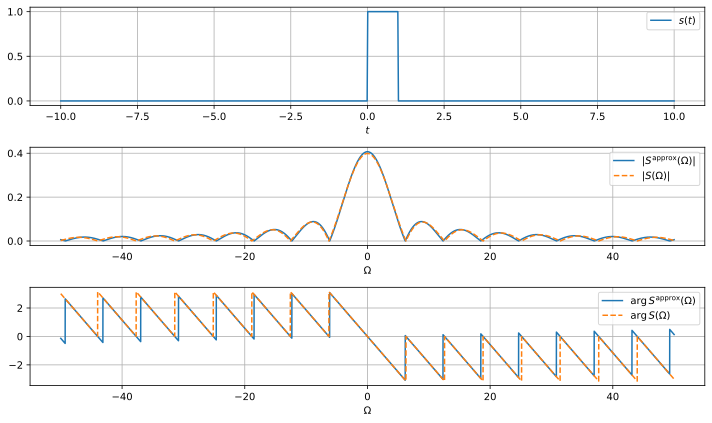

In [3]:
# Time grid
ts = np.linspace(-10.0, 10.0, 1000)
# Frequency grid
omegas = np.linspace(-50.0, 50.0, 10000)

fig, axes = plt.subplots(3, 1, figsize=(10, 6))

S_num = S_approx(omegas)
S_ana = S(omegas)

axes[0].plot(ts, s(ts), label=r'$s(t)$')

axes[1].plot(omegas, np.abs(S_num), label=r'$|S^{\mathrm{approx}}(\Omega)|$')
axes[1].plot(omegas, np.abs(S_ana), '--', label=r'$|S(\Omega)|$')

axes[2].plot(omegas, np.angle(S_num), label=r'$\arg S^{\mathrm{approx}}(\Omega)$')
axes[2].plot(omegas, np.angle(S_ana), '--', label=r'$\arg S(\Omega)$')

axes[0].set_xlabel('$t$')
axes[1].set_xlabel(r'$\Omega$')
axes[2].set_xlabel(r'$\Omega$')

axes[0].legend(loc='upper right')
axes[1].legend(loc='upper right')
axes[2].legend(loc='upper right')
axes[0].grid(True)
axes[1].grid(True)
axes[2].grid(True)

fig.tight_layout()
plt.show()


**Task 3:** 

Let the rectangular pulses now repeat with a period of $T$:
$$
x(t + nT) = s(t) \;\;\forall t\in[0, T], \;\;\forall n \in \mathbb{Z}
$$

* How will the Fourier Series coefficients $X_{n}$ for the signal $x(t) \in L^{2}[0, T]$ be related to the Fourier Integral $S(\Omega)$?
* Plot the graph of the Fourier Series coefficients ($\tau = 1, \frac{T}{\tau} = 4$).

*Your answer here:*

For $\Omega_n=\dfrac{2\pi n}{T}$

$$
X_n=\frac{1}{T}\int_{0}^{T} s(t)\,e^{-j\Omega_n t}\,dt
=\frac{\sqrt{2\pi}}{T}\,S(\Omega_n)
=\frac{\tau}{T}\,e^{-j\Omega_n\tau/2}\operatorname{sinc}\!\left(\frac{\Omega_n\tau}{2\pi}\right)
=\frac{\tau}{T}\,e^{-j\pi n\tau/T}\operatorname{sinc}\!\left(\frac{n\tau}{T}\right).
$$

In [ ]:
tau = 1.0
T = 4.0 * tau

@np.vectorize
def x(t, T, tau):
    t_mod = np.mod(t, T)
    return 1.0 if t_mod <= tau else 0.0


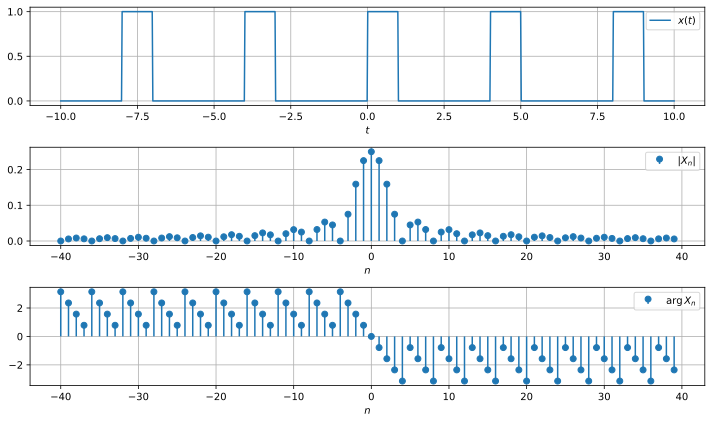

In [5]:
# Time grid
ts = np.linspace(-10.0, 10.0, 1000)

# Frequency grid
ns = np.arange(-40, 40)
wns = 2.0 * np.pi * ns / T

fig, axes = plt.subplots(3, 1, figsize=(10, 6))

X_n = (tau / T) * np.exp(-1j * wns * tau / 2.0) * np.sinc(wns * tau / (2.0 * np.pi))

axes[0].plot(ts, x(ts, T, tau), label=r'$x(t)$')

axes[1].stem(ns, np.abs(X_n), basefmt=' ', label=r'$|X_n|$')
axes[2].stem(ns, np.angle(X_n), basefmt=' ', label=r'$\arg X_n$')

axes[0].set_xlabel('$t$')
axes[1].set_xlabel('$n$')
axes[2].set_xlabel('$n$')

axes[0].legend(loc='upper right')
axes[1].legend(loc='upper right')
axes[2].legend(loc='upper right')
axes[0].grid(True)
axes[1].grid(True)
axes[2].grid(True)

fig.tight_layout()
plt.show()


**Task 4:** 

Let's consider the sampling of the signal $s(t)$ on a uniform grid. Suppose that on the interval from $0$ to $T$ there are $N=32$ samples ($\Delta t = \frac{T}{N}$). Calculate the Discrete-Time Fourier Transform of the signal $s[n] \in l^{2}$.

* Compare the resulting spectrum $S(e^{j\omega})$ with the Fourier Integral $S(\Omega)$.
    * The final expression for $S(e^{j\omega})$ should not contain sums. **Use the Dirichlet Kernel in the final formula!**
* Plot the graph on the given discrete frequency grid. **Use `scipy.special.diric`!**

*Your answer here:*

With $\Delta t=T/N$, the samples $s[n]=s(n\Delta t)$ are $1$ for $n=0,1,\dots,M$ and $0$ otherwise, where $M=\lfloor\tau/\Delta t\rfloor=\lfloor N\tau/T\rfloor$.  Hence

$$
S(e^{j\omega})=\sum_{n=0}^{M}e^{-j\omega n}
=e^{-j\omega M/2}\,\frac{\sin\!\big(\omega(M+1)/2\big)}{\sin(\omega/2)}
=(M+1)\,e^{-j\omega M/2}\,\mathcal{D}_{M+1}(\omega),
$$

where $\mathcal{D}_{N}(\omega)=\dfrac{\sin(N\omega/2)}{N\sin(\omega/2)}$ is the Dirichlet kernel.

Comparison with the Fourier integral: the DTFT is periodic (period $2\pi$) whereas $S(\Omega)$ is not, at low frequencies the two curves coincide (up to the sampling scale factor $\Delta t$), but as $|\omega|$ grows the DTFT bends away because of the replicas created by sampling.


In [ ]:
N = 32

@np.vectorize
def s_d(n, N, T, tau):
    dt = T / N
    return 1.0 if (0 <= n) and (n * dt <= tau) else 0.0

@np.vectorize
def S_DTFT(w, N, T, tau):
    dt = T / N
    M = int(np.floor(tau / dt))
    return (M + 1) * np.exp(-1j * w * M / 2.0) * scipy.special.diric(w, M + 1)


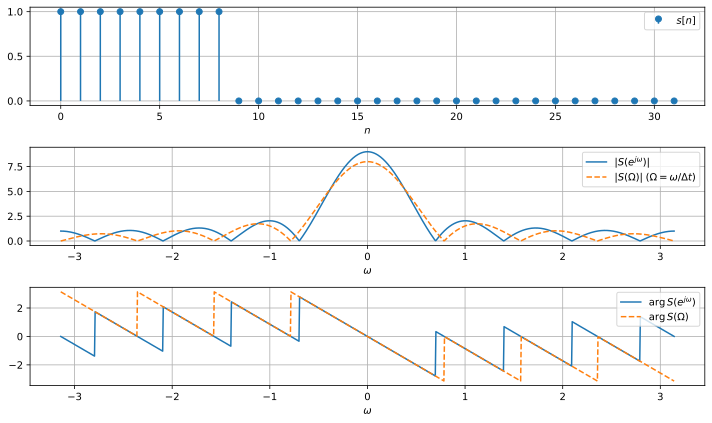

In [ ]:
# Samples grid
ns = np.arange(0, N)

# Frequency grid
ws = np.linspace(-np.pi, np.pi, 1000)

dt = T / N
s_samples = s_d(ns, N, T, tau)
S_dtft = S_DTFT(ws, N, T, tau)

S_int = S(ws / dt) * np.sqrt(2.0 * np.pi) / dt

fig, axes = plt.subplots(3, 1, figsize=(10, 6))

axes[0].stem(ns, s_samples, basefmt=' ', label=r'$s[n]$')

axes[1].plot(ws, np.abs(S_dtft), label=r'$|S(e^{j\omega})|$')
axes[1].plot(ws, np.abs(S_int), '--', label=r'$|S(\Omega)|\;(\Omega=\omega/\Delta t)$')

axes[2].plot(ws, np.angle(S_dtft), label=r'$\arg S(e^{j\omega})$')
axes[2].plot(ws, np.angle(S_int), '--', label=r'$\arg S(\Omega)$')

axes[0].set_xlabel('$n$')
axes[1].set_xlabel(r'$\omega$')
axes[2].set_xlabel(r'$\omega$')

axes[0].legend(loc='upper right')
axes[1].legend(loc='upper right')
axes[2].legend(loc='upper right')
axes[0].grid(True)
axes[1].grid(True)
axes[2].grid(True)

fig.tight_layout()
plt.show()


**Task 5:** 

For some reason, the magnitudes and zeros of the analytical expression for the DTFT do not match the magnitudes and zeros of the Fourier Integral, especially at high frequencies. **Explain why?**

*Your answer here:*

Two effects conspire:

1. Sampling $s(t)$ with step $\Delta t$ produces a spectrum that is the periodic sum $\sum_{k}S\!\big((\omega+2\pi k)/\Delta t\big)$.  High-frequency tails of $S(\Omega)$ fold back into the first period $[-\pi,\pi]$, destroying the exact zeros and changing the amplitudes.

2. The sampled pulse contains $M+1=\lfloor N\tau/T\rfloor+1$ ones, whose total duration is $(M+1)\Delta t$, not $\tau$.  The DTFT therefore corresponds to a rectangle of slightly different length, and its zeros are at $\omega=\dfrac{2\pi k}{M+1}$ instead of at $\Omega=\dfrac{2\pi k}{\tau}$.

**Task 6:** 

Let's consider a periodic discrete signal $x[n] \in \mathbb{R}^{N}$ and calculate its Discrete Fourier Transform $X^{\text{DFT}}_{n}$. 

* Compare the analytical formula for $X^{\text{DFT}}_{n}$ and the DTFT values $S(e^{j\omega})$.
* Plot the coefficients and the DTFT on the given discrete frequency grid.

*Your answer here:*

For the $N$-periodic $x[n]=s[n\!\!\mod N]$,

$$
X^{\mathrm{DFT}}_k=\sum_{n=0}^{N-1}x[n]\,e^{-j\frac{2\pi kn}{N}}
=\sum_{n=0}^{M}e^{-j\frac{2\pi kn}{N}}
=S\!\left(e^{j\omega}\right)\Big|_{\omega=\frac{2\pi k}{N}}.
$$

the DFT of one period equals the DTFT sampled at $\omega_k=2\pi k/N$.

In [8]:
@np.vectorize
def x_d(n, N, T, tau):
    dt = T / N
    n_mod = np.mod(n, N)
    return 1.0 if n_mod * dt <= tau else 0.0


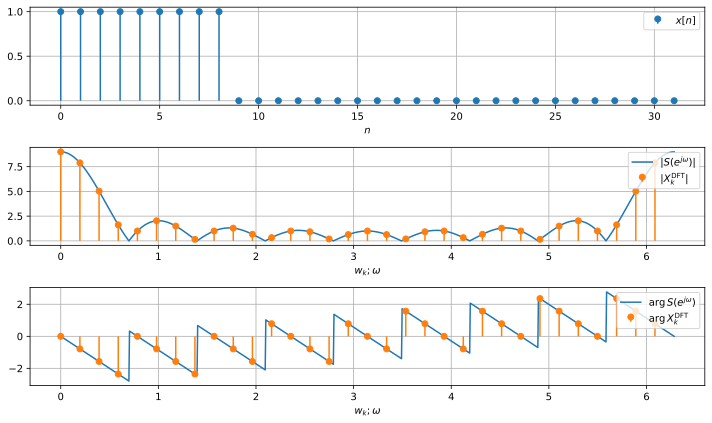

In [9]:
# Samples grid
ns = np.arange(0, N)

# DFT frequency grid
ws_dft = 2 * np.pi * ns / N

# DTFT frequency grid
ws = np.linspace(0.0, 2 * np.pi, 1000)

x_samples = x_d(ns, N, T, tau)
X_dft = np.fft.fft(x_samples)
S_dtft = S_DTFT(ws, N, T, tau)

fig, axes = plt.subplots(3, 1, figsize=(10, 6))

axes[0].stem(ns, x_samples, basefmt=' ', label=r'$x[n]$')

axes[1].plot(ws, np.abs(S_dtft), label=r'$|S(e^{j\omega})|$')
axes[1].stem(ws_dft, np.abs(X_dft), basefmt=' ', linefmt='C1-', markerfmt='C1o', label=r'$|X_k^{\mathrm{DFT}}|$')

axes[2].plot(ws, np.angle(S_dtft), label=r'$\arg S(e^{j\omega})$')
axes[2].stem(ws_dft, np.angle(X_dft), basefmt=' ', linefmt='C1-', markerfmt='C1o', label=r'$\arg X_k^{\mathrm{DFT}}$')

axes[0].set_xlabel('$n$')
axes[1].set_xlabel(r'$w_{k}; \omega$')
axes[2].set_xlabel(r'$w_{k}; \omega$')

axes[0].legend(loc='upper right')
axes[1].legend(loc='upper right')
axes[2].legend(loc='upper right')
axes[0].grid(True)
axes[1].grid(True)
axes[2].grid(True)

fig.tight_layout()
plt.show()


**Task 7:** 

How will the discrete spectrum $X^{\text{DFT}}_k$ change if the discrete signal $x^{\times 2}[n]$ in the time domain consists of two periods with a total length of $2N$ samples? 

* Describe the characteristic appearance of the resulting graph based on the analytical solution.
* Plot the spectrum $X^{\times 2, \text{DFT}}_k$ and $S(e^{j\omega})$ on the given discrete frequency grid.

*Your answer here:*

Let $x^{\times 2}[n]=x[n\!\!\mod N]$ for $n=0,\dots,2N-1$.  Its DFT of length $2N$ is

$$
X^{\times 2,\mathrm{DFT}}_k=\sum_{n=0}^{2N-1}x[n\!\!\mod N]\,e^{-j\frac{2\pi kn}{2N}}
= \big(1+e^{-j\pi k}\big)\sum_{n=0}^{N-1}x[n]\,e^{-j\frac{2\pi kn}{2N}}.
$$

The factor $1+e^{-j\pi k}=0$ for odd $k$ and $=2$ for even $k=2m$, giving

$$
X^{\times 2,\mathrm{DFT}}_{2m}=2\,X^{\mathrm{DFT}}_{m},\qquad X^{\times 2,\mathrm{DFT}}_{2m+1}=0.
$$

Graphically: the original DFT is repeated twice (non-zero on even indices only), and its envelope still coincides with the DTFT samples on a grid twice as dense.


In [10]:
@np.vectorize
def x_2_d(n, N, T, tau):
    return x_d(np.mod(n, N), N, T, tau)


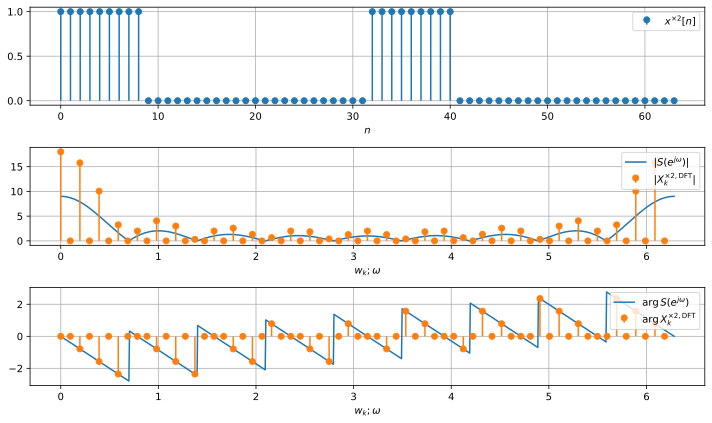

In [11]:
# Samples grid
ns = np.arange(0, 2 * N)

# DFT frequency grid
ws_dft = 2 * np.pi * ns / (2 * N)

# DTFT frequency grid
ws = np.linspace(0.0, 2 * np.pi, 1000)

x2_samples = x_2_d(ns, N, T, tau)
X2_dft = np.fft.fft(x2_samples)
S_dtft = S_DTFT(ws, N, T, tau)

fig, axes = plt.subplots(3, 1, figsize=(10, 6))

axes[0].stem(ns, x2_samples, basefmt=' ', label=r'$x^{\times 2}[n]$')

axes[1].plot(ws, np.abs(S_dtft), label=r'$|S(e^{j\omega})|$')
axes[1].stem(ws_dft, np.abs(X2_dft), basefmt=' ', linefmt='C1-', markerfmt='C1o', label=r'$|X_k^{\times 2,\mathrm{DFT}}|$')

axes[2].plot(ws, np.angle(S_dtft), label=r'$\arg S(e^{j\omega})$')
axes[2].stem(ws_dft, np.angle(X2_dft), basefmt=' ', linefmt='C1-', markerfmt='C1o', label=r'$\arg X_k^{\times 2,\mathrm{DFT}}$')

axes[0].set_xlabel('$n$')
axes[1].set_xlabel(r'$w_{k}; \omega$')
axes[2].set_xlabel(r'$w_{k}; \omega$')

axes[0].legend(loc='upper right')
axes[1].legend(loc='upper right')
axes[2].legend(loc='upper right')
axes[0].grid(True)
axes[1].grid(True)
axes[2].grid(True)

fig.tight_layout()
plt.show()


**Task 8:**

Let's now consider another modification of the original signal $x[n]$. Suppose the original signal contains $M + 1 = \lfloor N \frac{\tau}{T} \rfloor + 1$ ones in its sampled version. Let's pad the signal with $Q$ zeros at the end so that the final length of the signal becomes $N + Q$. 

* Analytically derive the DFT $X^{+, \text{DFT}}[n]$ of the signal $x^{+}[n]$.
* Compare the resulting formula with the DTFT $S(e^{j\omega})$.
* How will the spectrum change as $Q$ increases?
* Verify your conclusions by plotting the spectrum $X^{+, \text{DFT}}_k$ and $S(e^{j\omega})$ ($Q = 28$) on the given discrete frequency grid.

*Your answer here:*

For the zero-padded signal $x^{+}[n]$ of length $N+Q$ containing $M+1$ ones followed by zeros,

$$
X^{+,\mathrm{DFT}}_k
=\sum_{n=0}^{M}e^{-j\frac{2\pi kn}{N+Q}}
=e^{-j\pi k M/(N+Q)}\,\frac{\sin\!\big(\pi k(M+1)/(N+Q)\big)}{\sin\!\big(\pi k/(N+Q)\big)}
=(M+1)\,e^{-j\pi kM/(N+Q)}\,\mathcal D_{M+1}\!\big(2\pi k/(N+Q)\big)
=S(e^{j\omega})\Big|_{\omega=\frac{2\pi k}{N+Q}}.
$$

So zero-padding in the time domain $\Leftrightarrow$ sampling the DTFT on a denser frequency grid ($N+Q$ points instead of $N$): the underlying DTFT envelope is the same, we merely interpolate it in frequency.  As $Q\to\infty$ we sample the continuous DTFT arbitrarily densely.


In [12]:
Q = 28

@np.vectorize
def x_p_d(n, N, T, tau):
    dt = T / N
    if 0 <= n < N and n * dt <= tau:
        return 1.0
    return 0.0


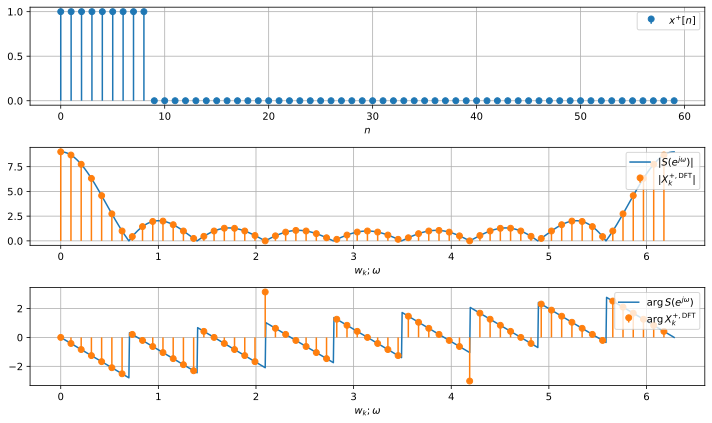

In [13]:
# Samples grid
ns = np.arange(0, N + Q)

# DFT frequency grid
ws_dft = 2 * np.pi * ns / (N + Q)

# DTFT frequency grid
ws = np.linspace(0.0, 2 * np.pi, 1000)

xp_samples = x_p_d(ns, N, T, tau)
Xp_dft = np.fft.fft(xp_samples)
S_dtft = S_DTFT(ws, N, T, tau)

fig, axes = plt.subplots(3, 1, figsize=(10, 6))

axes[0].stem(ns, xp_samples, basefmt=' ', label=r'$x^{+}[n]$')

axes[1].plot(ws, np.abs(S_dtft), label=r'$|S(e^{j\omega})|$')
axes[1].stem(ws_dft, np.abs(Xp_dft), basefmt=' ', linefmt='C1-', markerfmt='C1o', label=r'$|X_k^{+,\mathrm{DFT}}|$')

axes[2].plot(ws, np.angle(S_dtft), label=r'$\arg S(e^{j\omega})$')
axes[2].stem(ws_dft, np.angle(Xp_dft), basefmt=' ', linefmt='C1-', markerfmt='C1o', label=r'$\arg X_k^{+,\mathrm{DFT}}$')

axes[0].set_xlabel('$n$')
axes[1].set_xlabel(r'$w_{k}; \omega$')
axes[2].set_xlabel(r'$w_{k}; \omega$')

axes[0].legend(loc='upper right')
axes[1].legend(loc='upper right')
axes[2].legend(loc='upper right')
axes[0].grid(True)
axes[1].grid(True)
axes[2].grid(True)

fig.tight_layout()
plt.show()


## `1.2. Aliasing`

In this section, we will study the spectral properties of a zero-mean Gaussian:
$$
x_{\mathcal{N}}(t) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{t^2}{2\sigma^2}\right)
$$

**Task 9:**

* Calculate the Fourier Integral $X_{\mathcal{N}}(\Omega)$ of the signal $x_{\mathcal{N}}(t)$.
* Let's bound the signal to a certain range $[-T, T)$, how will its spectrum $X_{\mathcal{N}}^{T}(\Omega)$ change?
* Derive the analytical formula for $X_{\mathcal{N}}^{T}(\Omega)$ and analyze it. In what frequency range does this formula make sense?

*Your answer here:*

With the symmetric convention

$$
X_{\mathcal N}(\Omega)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^{+\infty}\frac{1}{\sqrt{2\pi\sigma^2}}e^{-t^2/(2\sigma^2)}e^{-j\Omega t}\,dt
=\frac{1}{\sqrt{2\pi}}\,e^{-\sigma^2\Omega^2/2}.
$$

Truncation to $[-T,T)$ is multiplication by a rectangular window $\mathrm{rect}(t/2T)$, so in frequency:

$$
X_{\mathcal N,T}(\Omega)=X_{\mathcal N}(\Omega)\;*\;\frac{T}{\sqrt{\pi/2}}\,\operatorname{sinc}\!\left(\frac{\Omega T}{\pi}\right)
$$

i.e. a Gaussian smeared by a sinc, giving visible side-lobes (ripples) outside the main bump.  As $T\to\infty$ the sinc approaches $\delta(\Omega)$ and $X_{\mathcal N,T}\to X_{\mathcal N}$.


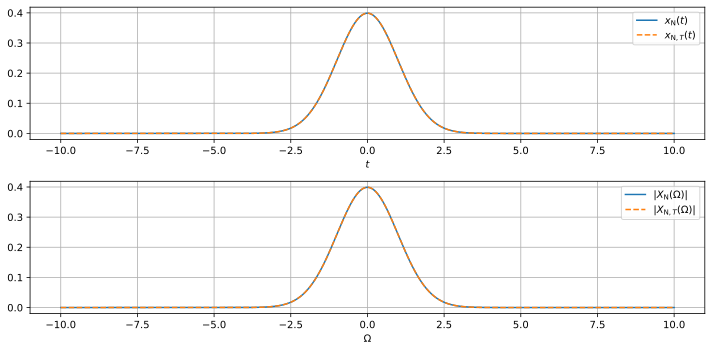

In [ ]:
sigma = 1.0
T_w = 5.0

ts = np.linspace(-10.0, 10.0, 4000)
omegas = np.linspace(-10.0, 10.0, 4000)

x_gauss = (1.0 / np.sqrt(2.0 * np.pi * sigma ** 2)) * np.exp(-ts ** 2 / (2.0 * sigma ** 2))
X_gauss_analytic = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-sigma ** 2 * omegas ** 2 / 2.0)

x_trunc = np.where(np.abs(ts) < T_w, x_gauss, 0.0)
dt = ts[1] - ts[0]
X_trunc = np.array([
    (dt / np.sqrt(2.0 * np.pi)) * np.sum(x_trunc * np.exp(-1j * om * ts))
    for om in omegas
])

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].plot(ts, x_gauss, label=r'$x_\mathrm{N}(t)$')
axes[0].plot(ts, x_trunc, '--', label=r'$x_{\mathrm{N},T}(t)$')
axes[0].set_xlabel('$t$'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(omegas, np.abs(X_gauss_analytic), label=r'$|X_\mathrm{N}(\Omega)|$')
axes[1].plot(omegas, np.abs(X_trunc), '--', label=r'$|X_{\mathrm{N},T}(\Omega)|$')
axes[1].set_xlabel(r'$\Omega$'); axes[1].legend(); axes[1].grid(True)

fig.tight_layout(); plt.show()


**Task 10:**

Let's try to sample this signal.

* Is it possible to do this without loss?
* Let's divide the range $[-T, T]$ into $N$ samples with a sampling period $\Delta t = \frac{2T}{N}, \Omega_s = \frac{2\pi}{\Delta t}$. Analytically and numerically simulate the aliasing that would occur when digitizing the analog signal using the formulas from the Nyquist-Shannon sampling theorem from *Seminar 03*.
* Compare it with the spectrum of the continuous truncated signal for a couple of $N$ values, for example, $64$ and $8$ ($\sigma = 1, T = 4$).
* In which region do the differences in the spectra appear, and why does this happen?

*Your answer here:*

A Gaussian is not band-limited, therefore, strictly speaking, it cannot be sampled without loss. However, its spectrum decays as $e^{-\sigma^2\Omega^2/2}$, which is extremely fast, so for a reasonable sampling frequency $\Omega_s$ the energy above $\Omega_s/2$ is negligible and the aliasing error is exponentially small.

The sampled spectrum $\hat X(\Omega)=\dfrac{1}{\Delta t}\sum_{k\in\mathbb Z} X_{\mathcal N}(\Omega-k\Omega_s)$ starts to deviate visibly from $X_{\mathcal N}$ only when $\sigma\Omega_s/2\lesssim 3$, i.e. when $\Delta t\gtrsim \sigma$.


In [ ]:
@np.vectorize
def x_N(t, sigma):
    return 1.0 / np.sqrt(2.0 * np.pi * sigma ** 2) * np.exp(-t ** 2 / (2.0 * sigma ** 2))

@np.vectorize
def X_N(omega, sigma):
    return 1.0 / np.sqrt(2.0 * np.pi) * np.exp(-sigma ** 2 * omega ** 2 / 2.0)

def X_N_T(omega, sigma, T):
    ts = np.linspace(-T, T, 4000, endpoint=False)
    dt = ts[1] - ts[0]
    xw = x_N(ts, sigma)
    omega = np.asarray(omega)
    return (dt / np.sqrt(2.0 * np.pi)) * (xw[None, :] * np.exp(-1j * omega[:, None] * ts[None, :])).sum(axis=1)


In [ ]:
def simulate_aliasing(sigma, T, N):
    delta_t = 2 * T / N
    Omega_s = 2.0 * np.pi / delta_t

    # Time grid
    ts = np.linspace(-T, T, 1000)

    # Time samples grid
    ts_hat = np.linspace(-T, T, N, endpoint=False)

    # Frequency grid (continuous reference)
    omegas = np.linspace(-1.5 * Omega_s, 1.5 * Omega_s, 2000)
    
    # DFT frequency grid (one period of the sampled spectrum)
    omegas_hat = 2.0 * np.pi * np.fft.fftshift(np.fft.fftfreq(N, d=delta_t))

    xs = x_N(ts, sigma)
    xs_hat = x_N(ts_hat, sigma)

    X_true = X_N(omegas, sigma)
    X_hat = np.fft.fftshift(np.fft.fft(xs_hat)) * delta_t / np.sqrt(2.0 * np.pi)

    fig, axes = plt.subplots(2, 1, figsize=(10, 5))
    axes[0].plot(ts, xs, label=r'$x_\mathrm{N}(t)$')
    axes[0].stem(ts_hat, xs_hat, basefmt=' ', linefmt='C1-', markerfmt='C1o', label='samples')
    axes[0].set_xlabel('$t$'); axes[0].legend(); axes[0].grid(True)
    axes[0].set_title(rf'$\sigma={sigma},\;T={T},\;N={N},\;\Omega_s={Omega_s:.2f}$')

    axes[1].plot(omegas, np.abs(X_true), label=r'$|X_\mathrm{N}(\Omega)|$')
    axes[1].stem(omegas_hat, np.abs(X_hat), basefmt=' ', linefmt='C1-', markerfmt='C1o',
                 label=r'$|\hat X(\Omega_k)|$')
    axes[1].axvline(Omega_s / 2, color='gray', ls='--')
    axes[1].axvline(-Omega_s / 2, color='gray', ls='--')
    axes[1].set_xlabel(r'$\Omega$'); axes[1].legend(); axes[1].grid(True)

    fig.tight_layout(); plt.show()


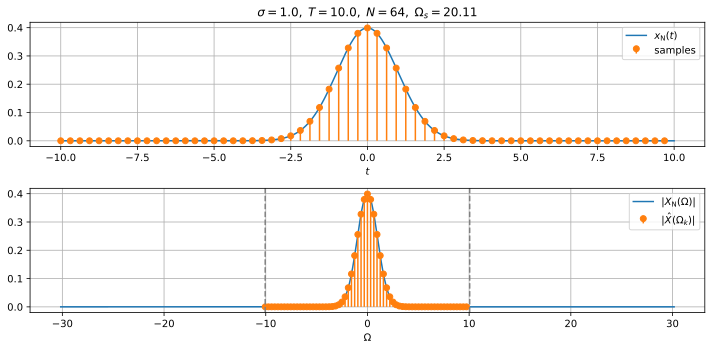

In [ ]:
simulate_aliasing(sigma=1.0, T=10.0, N=64)


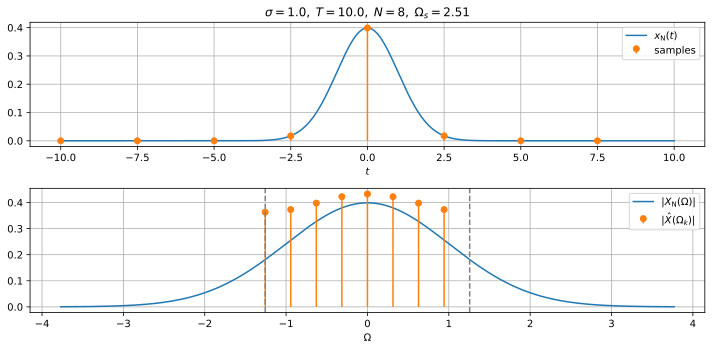

In [ ]:
simulate_aliasing(sigma=1.0, T=10.0, N=8)


## `1.3. Interpolation`

Now let's see how the spectrum of the signal $h[n]$ changes during its interpolation. We will consider an interpolation by a factor of $K=2$. For the task, you can take any signal of your own, or use the one provided below.

In [19]:
@np.vectorize
def h(t):
    return np.sin(16 * np.pi * t ** t)

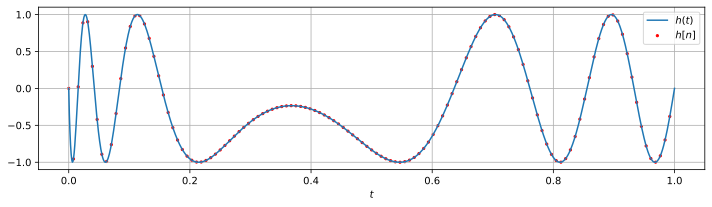

In [20]:
N, T = 128, 1.0

ts = np.linspace(0.0, T, 1000)
t_ds = np.linspace(0.0, T, N, endpoint=False)

hs = h(ts)
h_ds = h(t_ds)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.plot(ts, hs, label='$h(t)$')
ax.scatter(t_ds, h_ds, s=5, color='red', label='$h[n]$')

ax.set_xlabel('$t$')

ax.legend(loc='upper right')
ax.grid(True)

fig.tight_layout()
plt.show()

**Task 11:**

Interpolation can be considered as an increase in the sampling frequency while preserving the shape of the spectrum. Therefore, interpolation can be done in the spectral domain (Fourier interpolation). Similar to how the spectrum is interpolated by zero-padding in the time domain in the figure below, we can add $N\cdot(K-1)$ zeros to the spectrum (**exactly where?**) and obtain the interpolated signal $h^{i}[n]$ in the time domain (up to a scaling factor, **which one?**). Obviously, its spectrum $H^{i}[k]$ will remain unchanged. Numerically demonstrate the correctness of these operations.

![](https://ru.dsplib.org/content/dft_dtft/img/dft_dtft_fig4.png)

*Your answer here:*

Zero-pad the DFT **in the middle** (around the Nyquist index $N/2$), i.e. split the DFT into two halves $H[0\!:\!N/2]$ and $H[N/2\!:\!N]$ and insert $N(K-1)$ zeros between them.  This preserves hermitian symmetry for a real input and leaves all existing non-zero coefficients at the same physical frequencies.

After the inverse DFT, multiply the result by the scaling factor $K$ (equivalently, use `ifft` of the zero-padded spectrum with $N$-normalisation, i.e. divide by $N$ and multiply by $KN$).  Only then the interpolated samples match the true signal $h(t)$ at the new, $K$-times denser grid.


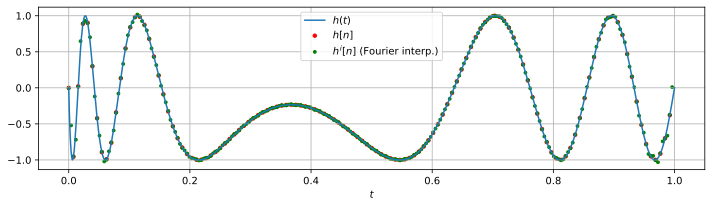

In [ ]:
K = 2

H = np.fft.fft(h_ds)
H_padded = np.concatenate([H[: N // 2], np.zeros(N * (K - 1), dtype=H.dtype), H[N // 2 :]])
H_padded[N // 2] *= 0.5
H_padded[N // 2 + N * (K - 1)] = H_padded[N // 2]

h_interp = np.fft.ifft(H_padded).real * K

t_ds_K = np.linspace(0.0, T, K * N, endpoint=False)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(ts, hs, label=r'$h(t)$')
ax.scatter(t_ds, h_ds, s=12, color='red', label=r'$h[n]$')
ax.scatter(t_ds_K, h_interp, s=8, color='green', label=r'$h^{i}[n]$ (Fourier interp.)')
ax.set_xlabel('$t$'); ax.legend(); ax.grid(True)
fig.tight_layout(); plt.show()


**Task 12:**

In stream processing of the signal $h[n]$, another method is often used: first, $K-1$ zeros are inserted between the samples, and then the resulting signal is filtered by a low-pass filter.

* Plot the spectrum of the signal $h_{1}[n]$, in which the samples are interlaced with zeros (even positions are values, odd are zeros, we consider interpolation by a factor of $2$). Alternatively, at this stage, the signal $h_{2}[n]$ can be used, where all samples are simply duplicated. How are the spectra of these two signals related?
* Based on the spectra from the previous point, explain why these signals need to be passed through a low-pass filter for interpolation, and do so using the provided functions.

As an LPF for interpolation by a factor of $2$, half-band filters $F$ are commonly used, which cut off exactly half of the spectrum. You can read about their construction [here](https://www.dsprelated.com/showcode/270.php). An example of constructing a filter $\hat{F}$ and using it is provided below:

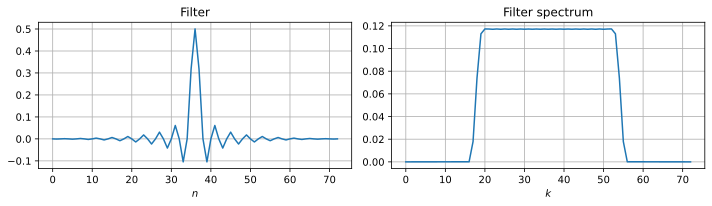

In [22]:
numtaps = 73
b = scipy.signal.firwin(numtaps, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(b)
axes[1].plot(np.absolute(fftshift(scipy.fft.fft(b, norm='ortho'))))

axes[0].set_title('Filter')
axes[1].set_title('Filter spectrum')

axes[0].set_xlabel(r'$n$')
axes[1].set_xlabel(r'$k$')

axes[0].grid(True)
axes[1].grid(True)

fig.tight_layout()
plt.show()

*Note: since the filter preserves causality (i.e., it cannot use data from the future), it introduces a certain delay, which, generally speaking, must be taken into account when aligning signals. For an FIR filter, it is always equal to half the number of taps, in this case $36$.*

*Note: the decimation problem is solved in a similar way: first, the signal is filtered using an LPF, after which every $K$-th sample is kept. If the signal is not pre-filtered, the aliasing effect will be observed, as the high frequencies present in the original signal will exceed the new Nyquist frequency, and the signal can be heavily distorted.*

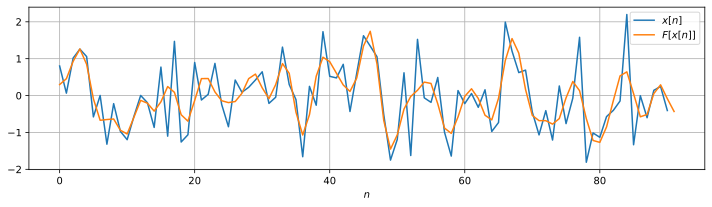

In [23]:
# Apply filter b to signal x
x = np.random.randn(128)
y = scipy.signal.lfilter(b, 1, x)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.plot(x[:-numtaps // 2], label='$x[n]$')
ax.plot(y[numtaps // 2:], label='$F[x[n]]$')

ax.set_xlabel('$n$')

ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

*Your answer here:*

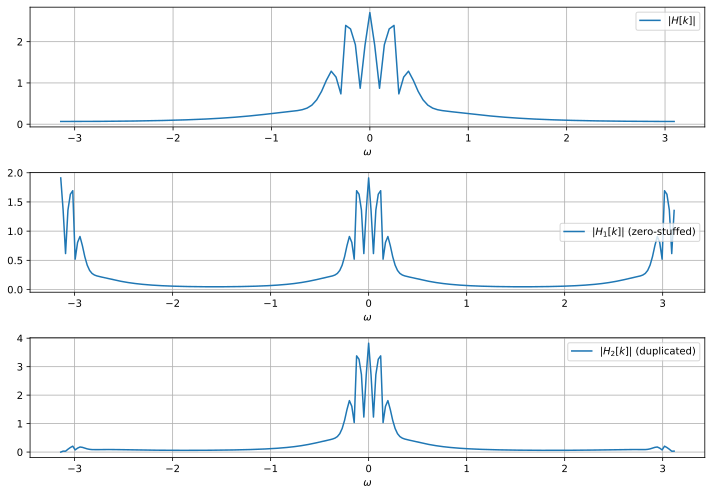

In [ ]:
K = 2

h1 = np.zeros(K * N)
h1[::K] = h_ds

h2 = np.repeat(h_ds, K)

H1 = np.fft.fftshift(np.fft.fft(h1, norm='ortho'))
H2 = np.fft.fftshift(np.fft.fft(h2, norm='ortho'))
H_orig = np.fft.fftshift(np.fft.fft(h_ds, norm='ortho'))

freqs_KN = np.fft.fftshift(np.fft.fftfreq(K * N)) * 2 * np.pi
freqs_N = np.fft.fftshift(np.fft.fftfreq(N)) * 2 * np.pi

fig, axes = plt.subplots(3, 1, figsize=(10, 7))
axes[0].plot(freqs_N, np.abs(H_orig), label=r'$|H[k]|$'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(freqs_KN, np.abs(H1), label=r'$|H_1[k]|$ (zero-stuffed)'); axes[1].legend(); axes[1].grid(True)
axes[2].plot(freqs_KN, np.abs(H2), label=r'$|H_2[k]|$ (duplicated)'); axes[2].legend(); axes[2].grid(True)
for ax in axes: ax.set_xlabel(r'$\omega$')
fig.tight_layout(); plt.show()

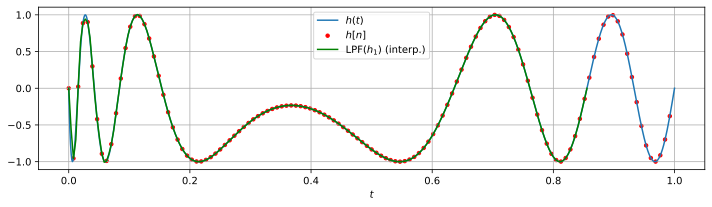

In [ ]:
numtaps = 73
b = scipy.signal.firwin(numtaps, 0.5)

y_filtered = K * scipy.signal.lfilter(b, 1.0, h1)
delay = numtaps // 2

t_ds_K = np.linspace(0.0, T, K * N, endpoint=False)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(ts, hs, label=r'$h(t)$')
ax.scatter(t_ds, h_ds, s=12, color='red', label=r'$h[n]$')
ax.plot(t_ds_K[:-delay], y_filtered[delay:], color='green', label=r'LPF($h_1$) (interp.)')
ax.set_xlabel('$t$'); ax.legend(); ax.grid(True)
fig.tight_layout(); plt.show()

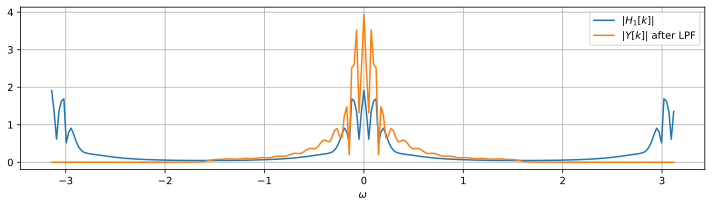

In [ ]:
Y = np.fft.fftshift(np.fft.fft(y_filtered, norm='ortho'))

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(freqs_KN, np.abs(H1), label=r'$|H_1[k]|$')
ax.plot(freqs_KN, np.abs(Y), label=r'$|Y[k]|$ after LPF')
ax.set_xlabel(r'$\omega$'); ax.legend(); ax.grid(True)
fig.tight_layout(); plt.show()

**Task 13:**

You are much more familiar with linear and cubic interpolation. Compare their spectra with the spectra from `Task 12`.

*Your answer here:*

Linear and cubic interpolation can both be written as FIR filters applied to the zero-stuffed signal (kernels $[1/2,1,1/2]$ for linear and the Keys cubic for cubic).  Compared to a half-band LPF, their frequency responses are much softer:

* Linear is a triangular pulse → $|F(\omega)|\propto\operatorname{sinc}^{2}(\omega/2)$: the half-band replica is attenuated only by ≈ 13 dB at $\omega=\pi$, and the pass-band is rounded off already well before the Nyquist frequency.
* Cubic has a tighter roll-off (≈ 30 dB at $\omega=\pi$) and a much flatter pass-band, but it still leaks some of the replica.

A half-band FIR filter performs much better than either of them, which is why it is the de-facto standard in high-quality interpolation.


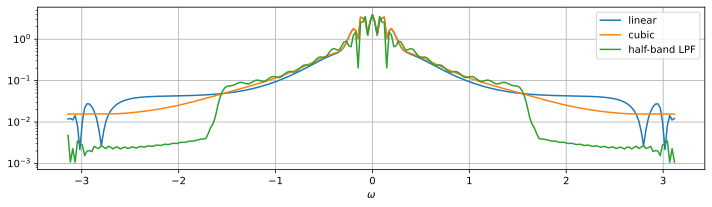

In [ ]:
K = 2

t_ds_K = np.linspace(0.0, T, K * N, endpoint=False)

lin_interp = np.interp(t_ds_K, t_ds, h_ds)
cubic_interp = scipy.interpolate.CubicSpline(t_ds, h_ds, bc_type='natural')(t_ds_K)

Y_lin = np.fft.fftshift(np.fft.fft(lin_interp, norm='ortho'))
Y_cub = np.fft.fftshift(np.fft.fft(cubic_interp, norm='ortho'))
Y_lpf = np.fft.fftshift(np.fft.fft(y_filtered, norm='ortho'))

freqs_KN = np.fft.fftshift(np.fft.fftfreq(K * N)) * 2 * np.pi

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(freqs_KN, np.abs(Y_lin), label='linear')
ax.plot(freqs_KN, np.abs(Y_cub), label='cubic')
ax.plot(freqs_KN, np.abs(Y_lpf), label='half-band LPF')
ax.set_xlabel(r'$\omega$'); ax.legend(); ax.grid(True); ax.set_yscale('log')
fig.tight_layout(); plt.show()


**Task 14:**

It turns out that linear interpolation is also a special case of filtering described in the previous point. Let $K=2$, what should the filter coefficients be then? Compare the spectral characteristics of such a filter with the filter from Task 12.

*Your answer here:*

For $K=2$, the linear interpolation of a zero-stuffed sequence is equivalent to filtering with the triangular kernel

$$
f=[1/2,\;1,\;1/2].
$$

Its frequency response is $F(\omega)=1+\cos\omega=2\cos^{2}(\omega/2)$, i.e. a raised cosine that is everywhere positive, with gain $1$ at $\omega=0$ and $0$ at $\omega=\pi$.  Compared to the half-band FIR (sharp transition, stop-band ≈ $10^{-2}$), the triangular filter has a very wide transition band and much weaker stop-band attenuation — which is why linear interpolation leaks imaging replicas.


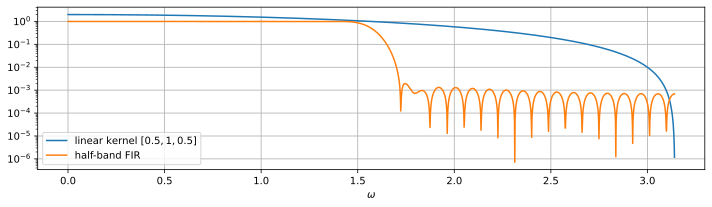

In [28]:
f_lin = np.array([0.5, 1.0, 0.5])
numtaps = 73
b_halfband = scipy.signal.firwin(numtaps, 0.5)

w, H_lin = scipy.signal.freqz(f_lin, worN=2048)
w, H_hb = scipy.signal.freqz(b_halfband, worN=2048)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(w, np.abs(H_lin), label='linear kernel $[0.5,1,0.5]$')
ax.plot(w, np.abs(H_hb), label='half-band FIR')
ax.set_xlabel(r'$\omega$'); ax.set_yscale('log'); ax.legend(); ax.grid(True)
fig.tight_layout(); plt.show()


# `Part 2`

## `1. Aircraft detection`

England, 1940. The British military is setting up a radar system for the early detection of enemy aircraft. On one quiet evening, you discover that the engineer who developed the radar made a software bug, and the data is currently being processed incorrectly. Nevertheless, an enemy plane has just flown by! Your task is to quickly fix the radar's software code to track the plane's trajectory and destroy it before it strikes the city. The fate of London is in your hands!

You currently have $20$ data samples from the radar, obtained at intervals of $5$ seconds. Each sample is a $64\times 64\times 64$ array of complex numbers reflecting the state of the surrounding space. Thus, all you have is a $20\times 64\times 64\times 64$ tensor and a surface-to-air missile. During each radar measurement, the plane resonates at a specific (unknown) frequency. The spectrum of such a signal will resemble a Gaussian centered at an unknown point. 

1. The first problem is that you do not know the exact frequency (it depends on the aircraft model), which makes the task somewhat complicated. 
2. The second problem is that bad weather conditions create strong interference, making the received signal uninterpretable.

(20, 64, 64, 64)


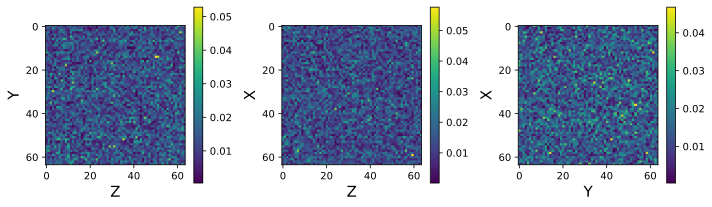

In [29]:
radar_signal = np.load('data/plane.npz')['plane']
print(radar_signal.shape)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axises = (('Y', 'Z'), ('X', 'Z'), ('X', 'Y'))
for ax, axis in zip(axes, range(3)):
    _ = ax.imshow(
        np.abs(radar_signal.mean(0).mean(axis))
    )
    plt.colorbar(_, ax=ax)
    ax.set_xlabel(axises[axis][1], fontsize=15)
    ax.set_ylabel(axises[axis][0], fontsize=15)

fig.tight_layout()
plt.show()

### `1.1 Frequency`

**Task 15:**

First, let's try to understand at what frequency the target signal is located. To do this, let's compute the 3D Fourier transform of our signal at each time step. As a result, we will get $20$ spectra. It is important to note that the complex argument of the noise component is different for each measurement. The useful signal, however, will have the same spectrum. Thus, by averaging the spectra over time, we will be able to find the target frequency, suppressing the noise. Average the spectra and find the target frequency (use the `fftn` function to get the spectrum). 

<i> For self-check: $f_{y} = 9$</i>

*Your answer here:*

The plane's frequency-domain signature is stationary in time, while the noise has a random phase that changes between measurements.  Averaging the magnitudes of the 3D spectra over the 20 time slices therefore sharpens the target peak while suppressing the noise.  The position of the maximum of the averaged magnitude spectrum gives the target frequency.


In [ ]:
spectra = np.fft.fftn(radar_signal, axes=(1, 2, 3))
mean_spectrum = np.abs(spectra.mean(axis=0))

ix, iy, iz = np.unravel_index(np.argmax(mean_spectrum), mean_spectrum.shape)
n = radar_signal.shape[1]
def to_signed(k):
    return k if k < n // 2 else k - n
f_x, f_y, f_z = to_signed(ix), to_signed(iy), to_signed(iz)

print(f'Peak bin (FFT indices): ({ix}, {iy}, {iz})')
print(f'Target frequency (signed): f_x={f_x}, f_y={f_y}, f_z={f_z}')


Peak bin (FFT indices): (59, 9, 0)
Target frequency (signed): f_x=-5, f_y=9, f_z=0


### `1.2 Building the filter`

**Task 16:**

Now we know the frequency around which we need to filter. Build a Gaussian filter ($\sigma = 10$) centered at the found frequency. Do not forget to account for the periodicity of the filter.

*Answer:*

The filter is a 3D Gaussian centered at the target frequency.  Because the DFT treats frequencies modulo $N$, the Gaussian must be periodically wrapped — the simplest way is to build the Gaussian on the signed axes $[-N/2,N/2)$, centre it at the signed target frequency, and `ifftshift` it before multiplying the spectrum.


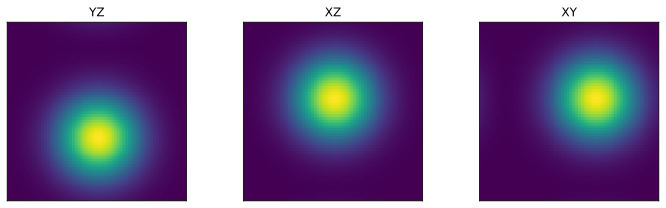

In [ ]:
sigma = 10.0

n = radar_signal.shape[1]
axis = np.arange(n) - n // 2
gx, gy, gz = np.meshgrid(axis, axis, axis, indexing='ij')

def periodic_delta(g, f, n):
    d = g - f
    return (d + n // 2) % n - n // 2

dx = periodic_delta(gx, f_x, n)
dy = periodic_delta(gy, f_y, n)
dz = periodic_delta(gz, f_z, n)

kernel_shifted = np.exp(-(dx ** 2 + dy ** 2 + dz ** 2) / (2.0 * sigma ** 2))
kernel = np.fft.ifftshift(kernel_shifted)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(kernel_shifted.sum(0)); axes[0].set_title('YZ')
axes[1].imshow(kernel_shifted.sum(1)); axes[1].set_title('XZ')
axes[2].imshow(kernel_shifted.sum(2)); axes[2].set_title('XY')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()


### `1.3 Filtering`

**Task 17:**

The final stage in aircraft detection is signal filtering. Calculate the spectrum of the signal at each time step and multiply it by the constructed kernel. Perform the inverse Fourier transform and find the aircraft coordinates. To what coordinates should the missile be launched?

*Your answer here:*

## `2. Images`

**Task 18:**

So, you managed to shoot down the plane. However, before crashing, it managed to send a signal — an encrypted image. During interception, the image became extremely noisy, and now you will have to try to suppress the noise to find out what is shown in the intercepted picture.

image shape: (900, 900, 3)


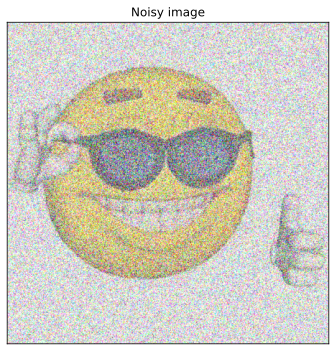

In [33]:
image = np.load('data/image.npz')['image']
print('image shape:', image.shape)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(np.clip(image, 0.0, 1.0))
ax.set_title('Noisy image'); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()


**Task 19:**

Display the spectrum of the image channels. Since the low-frequency component usually prevails in natural images, let's try to keep only it. To do this, build a low-pass filter and apply it to each channel. Finally, display the resulting image.

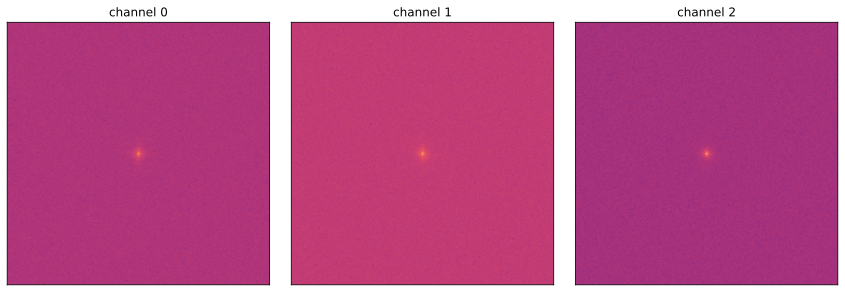

In [34]:
H_img = np.fft.fftshift(np.fft.fft2(image, axes=(0, 1)), axes=(0, 1))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for c, ax in enumerate(axes):
    ax.imshow(np.log1p(np.abs(H_img[:, :, c])), cmap='magma')
    ax.set_title(f'channel {c}'); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()


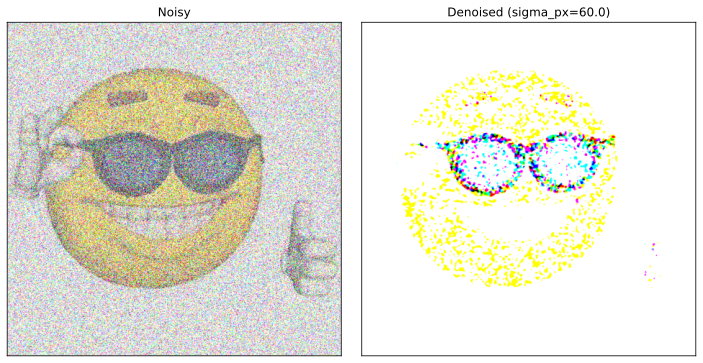

In [ ]:
H, W, C = image.shape
yy, xx = np.mgrid[:H, :W]
cy, cx = H // 2, W // 2
rad = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

sigma_px = 60.0
lpf = np.exp(-rad ** 2 / (2.0 * sigma_px ** 2))

H_filtered = H_img * lpf[:, :, None]
image_denoised = np.fft.ifft2(np.fft.ifftshift(H_filtered, axes=(0, 1)), axes=(0, 1)).real

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(np.clip(image, 0.0, 1.0)); axes[0].set_title('Noisy')
axes[1].imshow(np.clip(image_denoised, 0.0, 1.0)); axes[1].set_title(f'Denoised (sigma_px={sigma_px})')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()


## `3. Impulse response`

**Task 20:**

In the third part of the assignment, we will try to apply the linear filter framework to apply sound effects to audio. Take a voice recording from an anechoic chamber `"./data/singing.wav"` and the impulse response of some building `"./data/tunnel_new.wav"`. Modify the recording so that the voice sounds as if the recording was made in the chosen building. (Hint: use convolution).

Links: 
* <a href="https://www.openair.hosted.york.ac.uk/?page_id=310">Recordings from anechoic chamber</a>
* <a href="https://www.openair.hosted.york.ac.uk/?page_id=525">Impulse response example</a> 

*Note: be careful with the amplitudes — try not to go deaf. Also, pay attention to the system's sampling rate. They must be the same for both the impulse response and the voice recording. If they do not match, apply downsampling to one of the recordings.*

In [ ]:
voice_rate, voice = wavfile.read('data/singing.wav')
ir_rate, ir = wavfile.read('data/tunnel_new.wav')

voice = voice.astype(np.float64)
ir = ir.astype(np.float64)
if voice.ndim > 1: voice = voice.mean(axis=1)
if ir.ndim > 1:    ir = ir.mean(axis=1)

assert voice_rate == ir_rate, f'Sample rates differ: {voice_rate} vs {ir_rate}'
print(f'Sample rate: {voice_rate} Hz')

ir /= np.max(np.abs(ir))
out = scipy.signal.fftconvolve(voice, ir, mode='full')
out /= np.max(np.abs(out))
out_int16 = (out * 0.9 * np.iinfo(np.int16).max).astype(np.int16)

wavfile.write('data/singing_convolved.wav', voice_rate, out_int16)

print('Saved: data/singing_convolved.wav')
print('Original voice:')
IPython.display.display(IPython.display.Audio('data/singing.wav'))
print('Impulse response (tunnel):')
IPython.display.display(IPython.display.Audio('data/tunnel_new.wav'))
print('Convolved result:')
IPython.display.display(IPython.display.Audio('data/singing_convolved.wav'))


Sample rate: 48000 Hz
Saved: data/singing_convolved.wav
Original voice:


/var/folders/97/j4qkvjc90zqcw6hxynw7mhnc0000gn/T/ipykernel_19743/3098308029.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  voice_rate, voice = wavfile.read('data/singing.wav')


Impulse response (tunnel):


Convolved result:
